## Building a sentiment analyzer using the Naive Bayes algorithm
Sentiment analysis, sometimes called opinion mining or polarity detection, refers to the set of algorithms and techniques that are used to extract the polarity of a given document; that is, it determines whether the sentiment of a document is positive, negative, or
neutral. Sentiment analysis is gaining popularity in the industry as it allows organizations to mine opinions of a large group of users or potential customers in a cost-efficient
way. Sentiment analysis is now used extensively in advertisement campaigns, political campaigns, stock analysis, and more.

__We will build a sentiment analyzer by training our Naive Bayes model on a labeled product review dataset gathered from Amazon.__ 

As we can see, the `amazon_cells_labelled.txt` document contains a list of customer reviews and each review is assigned a sentiment score, with 0 representing __negative__ sentiment and 1 representing __positive__ sentiment.

In [3]:
import pandas as pd
data = pd.read_csv("Dataset/amazon_cells_labelled.txt", sep='\t', header=None)
data.head()

,0,1
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


In [4]:
X = data.iloc[:,0] # extract column with review
y = data.iloc[:,-1] # extract column with sentiment

### Tokenize the news text and convert data in matrix format

In [12]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
vectorizer = CountVectorizer(stop_words='english')
X_vec = vectorizer.fit_transform(X)
X_vec = X_vec.todense() # convert sparse matrix into dense matrix
X_vec=np.asarray(X_vec) # convert to numpy array
X_vec

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1000, 1642))

Here is the step-by-step breakdown:
1. `vectorizer = CountVectorizer(stop_words='english')` This initializes the Bag of Words model.CountVectorizer: It looks at every document, finds every unique word, and creates a column for each word. The values in the cells are the number of times that word appears.stop_words='english': This is a built-in filter. It tells the tool to ignore common English filler words like "the," "is," "and," or "in." These words appear so often they usually don't help the model learn anything useful.
2. `X_vec = vectorizer.fit_transform(X)` This does two jobs at once on your text data X:
    * `fit`: It scans your text to build a "vocabulary" (a master list of every unique word found).
    * `transform`: It converts the sentences into numbers based on that vocabulary.
    * `Result`: By default, scikit-learn stores this as a Sparse Matrix. This is a memory-saving format that only remembers where the non-zero numbers are (since most words don't appear in every single sentence).
3. `X_vec = X_vec.todense()` This converts the "Sparse Matrix" into a Dense Matrix (a standard 2D array/grid).
    * Why do this? Sparse matrices are hard for humans to read. Converting it to "dense" fills in all the zeros so you can see the full table
    * Warning: If you have a huge dataset (thousands of documents), a dense matrix can crash your computer's memory because it tries to store millions of zeros.

### Transform data by applying term frequency inverse document frequency (TF-IDF) 

Tf means term-frequency while tf-idf means term-frequency times inverse document-frequency. This is a common term weighting scheme in information retrieval, that has also found good use in document classification.

The goal of using tf-idf instead of the raw frequencies of occurrence of a token in a given document is to scale down the impact of tokens that occur very frequently in a given corpus and that are hence empirically less informative than features that occur in a small fraction of the training corpus.

In [13]:
from sklearn.feature_extraction.text import TfidfTransformer
tfidf = TfidfTransformer() #by default applies "l2" normalization
X_tfidf = tfidf.fit_transform(X_vec)
X_tfidf = X_tfidf.todense()
X_tfidf

matrix([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(1000, 1642))

We need to split the data into training and testing sets so that we can evaluate the performance of our trained model. This is called __cross-validation__ and is an important part of ML model training.

################## Apply Naive Bayes algorithm to train data ####################

### Extract the news body and labels for training the classifier

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(np.asarray(X_tfidf), y, test_size = 0.25, random_state = 0)

## Naive Bayes algorithm: 

The Naive Bayes algorithm is a supervised machine learning algorithm used for classification tasks. It is based on Bayes' Theorem, a mathematical formula for determining the probability of an event based on prior knowledge of related conditions.

Why is it "Naive"?\
The algorithm is called "naive" because it makes a strong simplifying assumption: all features used for prediction are independent of one another. In reality, features often correlate (e.g., in weather, high humidity and rain are related), but Naive Bayes treats each as if it contributes independently to the outcome, which significantly speeds up computation.

Key Strengths and Weaknesses
* __Pros__: It is extremely fast, highly scalable, and performs surprisingly well even with small datasets or high-dimensional data like text.
* __Cons__: It assumes feature independence, which is rarely true in real life, and it can suffer from the "Zero-Frequency Problem"—if a feature was never seen in training, it assigns a 0% probability to the whole class (often solved using Laplace smoothing).

Common Applications
* Spam Filtering
* Sentiment Analysis
* Document Categorization
* Medical Diagnosis


### Train the NB classifier

In [17]:
from sklearn.naive_bayes import MultinomialNB
clf = MultinomialNB()
clf.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


Fitting the training data essentially means that our Naive Bayes classifier has now learned the training data and is now in a position to calculate relevant probabilities.

### Predicting the Test set results

In [18]:
y_pred = clf.predict(X_test)

In [23]:
# Test the classifier on custom reviews
custom_reviews = [
    "This product is amazing! I love it.",
    "Terrible quality, very disappointed.",
    "It's okay, nothing special.",
    "Best purchase ever, highly recommend!"
]

# Transform custom reviews using the same vectorizer and tfidf transformer
custom_vec = vectorizer.transform(custom_reviews)
custom_tfidf = tfidf.transform(custom_vec)
custom_tfidf = np.asarray(custom_tfidf.todense())

In [24]:
predictions = clf.predict(custom_tfidf)

In [25]:
for review, prediction in zip(custom_reviews, predictions):
    sentiment = "POSITIVE ✓" if prediction == 1 else "NEGATIVE ✗"
    print(f"Review: {review}")
    print(f"Prediction: {sentiment}\n")

Review: This product is amazing! I love it.
Prediction: POSITIVE ✓

Review: Terrible quality, very disappointed.
Prediction: NEGATIVE ✗

Review: It's okay, nothing special.
Prediction: NEGATIVE ✗

Review: Best purchase ever, highly recommend!
Prediction: POSITIVE ✓



To determine the performance of our model, we will create a confusion matrix that calculates the number of correct predictions, broken down for each classification.

### Confusion Matrix

In [26]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 87,  33],
       [ 20, 110]])

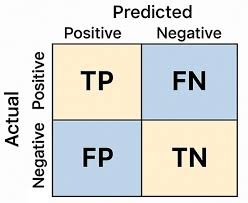

Hence, The vertical axis of sklearn's confusion matrix should be interpreted as the actual values, while the horizontal axis should be interpreted as the predicted values. Therefore, our model predicted 107 (87 + 20) values as having a sentiment score of 0, out which 87 were correctly predicted and 20 were incorrectly predicted. Likewise, the model predicted 143 (33+110) values as having a sentiment score of 1, out of which 110 were correctly predicted and 33 were incorrectly predicted.

Therefore, the total number of correct predictions is obtained by summing the left diagonal (in this case, `87 + 110`). The accuracy is the ratio of the __total correct predictions__ divided by the __total count of the test set__ (obtained by summing all the numbers in the confusion matrix). Therefore, the accuracy, in this case, is `197/250 = 78.8%`. This is a decent accuracy score given the simple model and limited training data we had (only 750 abridged reviews). Tuning model parameters and performing further preprocessing steps such as _lemmatization_, _stemming_, and so on can improve the accuracy further.

## The SVM algorithm

SVM is a __supervised ML algorithm__ that attempts to classify data within a dataset by finding the optimal hyperplane that best segregates the classes. Each data point in the dataset can be considered a vector in an N-dimensional plane, with each dimension representing a feature of the data. SVM identifies the frontier data points (or points closest to the opposing class), also known as support vectors, and then attempts to find the boundary (also known as the hyperplane in the N-dimensional space) that is the farthest from the support vector of each class.

########## Fitting SVM to the Training set ##########

In [27]:
from sklearn.svm import SVC
classifier = SVC(kernel='linear')
classifier.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [28]:
y_pred = classifier.predict(X_test)

In [29]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[102,  18],
       [ 33,  97]])

accuracy is around = 79.6%

### Pickling the model for reuse

In [33]:
import pickle
pickle.dump(vectorizer, open("Dataset/pickle_file/vectorizer_sa.pkl", 'wb')) # Save vectorizer for reuse
pickle.dump(classifier, open("Dataset/pickle_file/nb_sa.pkl", 'wb')) # Save classifier for reuse